In [1]:
import pandas as pd
url="https://raw.githubusercontent.com/anamikasharma20/Superstore-Sales-Dataset-Analysis/refs/heads/main/Superstore%20Sales%20Dataset.csv"
df=pd.read_csv(url)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(9800, 18)

In [2]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


The Postal Code contains 11 missing values out of 9800 which represents a very small proportion of the dataset, thus the percentage is negligible and can be ignored for future analysis.

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicated data was found.

In [7]:
df.select_dtypes(include=["float"]).columns

Index(['Postal Code', 'Sales'], dtype='object')

In [ ]:
important_cols = ["Ship Mode","Segment","Region","Category","Sub-Category"]

for col in important_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Ship Mode
Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

Column: Segment
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Column: Region
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

Column: Category
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

Column: Sub-Category
Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64


In [8]:
df['Category'].value_counts()

,count
Category,
Office Supplies,5909
Furniture,2078
Technology,1813


In [9]:
df['Region'].value_counts()

,count
Region,
West,3140
East,2785
Central,2277
South,1598


In [10]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5101
Corporate,2953
Home Office,1746


In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

<Axes: >

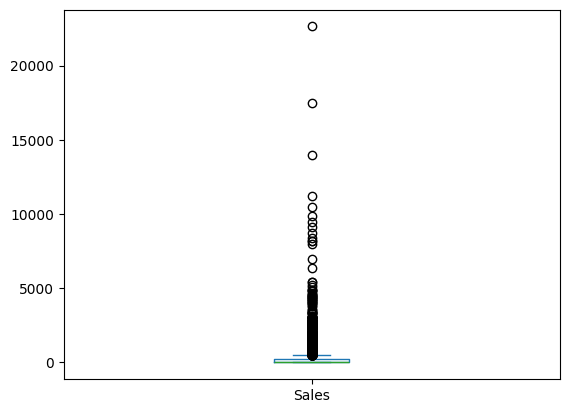

In [15]:
df['Sales'].plot(kind='box')


In [16]:
df.columns=df.columns.str.replace(" ","_")

EDA-(Exploratory Data Analysis)

In [17]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [ ]:
total_sales=df['Sales'].sum()
print("Total sales are: ",total_sales)


Total sales are:  2261536.7827000003


In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


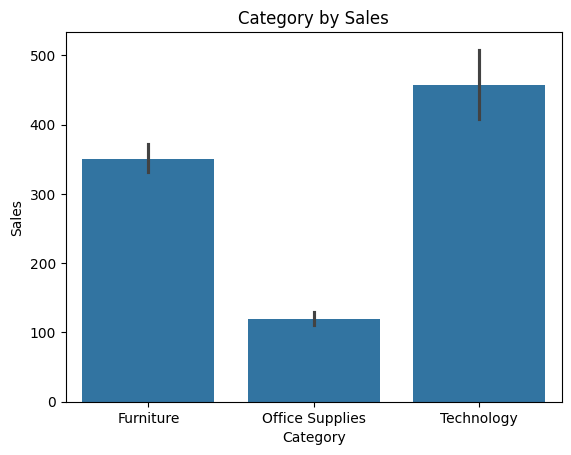

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Category',y='Sales',data=df)
plt.title("Category by Sales")
plt.show()

In [19]:
region_data=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)


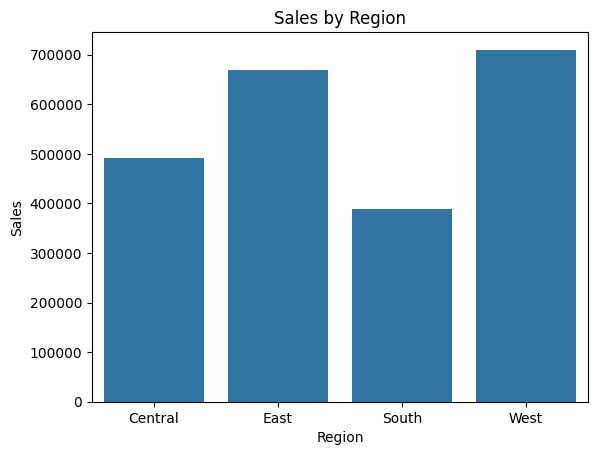

In [20]:
region_data=df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(x='Region',y='Sales',data=region_data)
plt.title("Sales by Region")
plt.show()

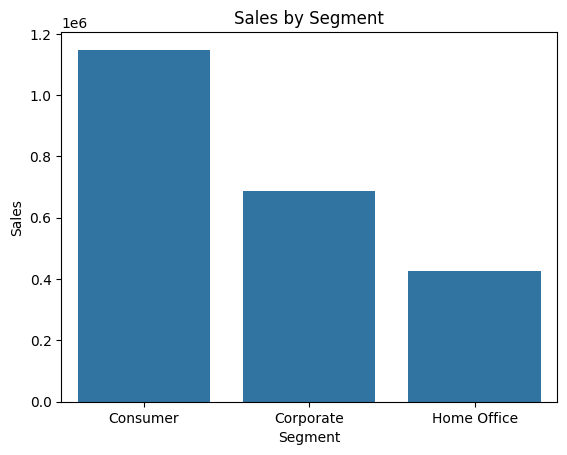

In [21]:
region_data=df.groupby('Segment')['Sales'].sum().reset_index()
sns.barplot(x='Segment',y='Sales',data=region_data)
plt.title("Sales by Segment")
plt.show()

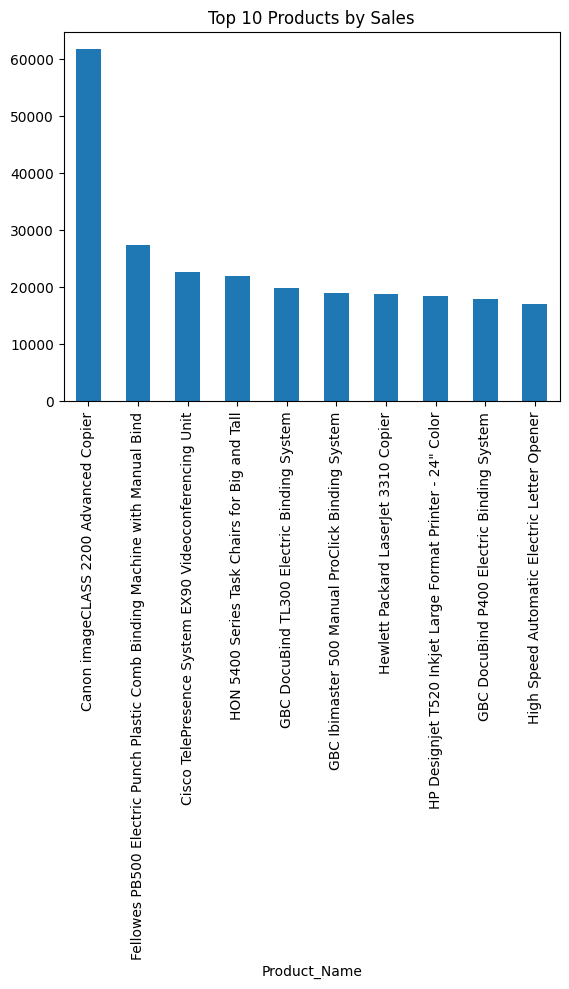

In [22]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.show()

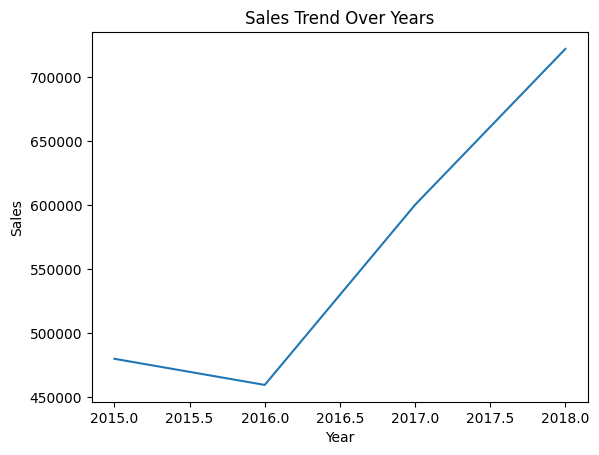

In [23]:
df["Year"] = df["Order_Date"].dt.year
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()
sns.lineplot(x="Year", y="Sales", data=yearly_sales)
plt.title("Sales Trend Over Years")
plt.show()

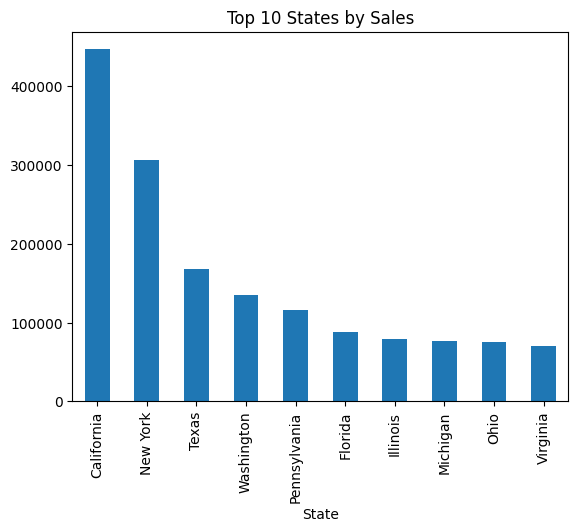

In [24]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.show()

Key Insights:

1. Technology category has highest sales.
2. West region is the top performing region.
3. Consumer segment contributes most revenue.
4. Sales are increasing over time.
5. Few products dominate the sales distribution.